In [2]:
!pip install transformers torch sentencepiece pandas scikit-learn nltk matplotlib seaborn datasets rouge-score sentence-transformers feedparser --quiet

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 7.5 MB/s eta 0:00:00


In [3]:
import json
import random
import re
import urllib.request
import warnings
from collections import Counter
from difflib import SequenceMatcher

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import T5ForConditionalGeneration, T5Tokenizer, Trainer, TrainingArguments

warnings.filterwarnings('ignore')

# Download NLTK data
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Set all seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Device configuration
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# Create output directory
import os
os.makedirs('output', exist_ok=True)


Using device: cuda


In [7]:
import pandas as pd
import json
import os

# Create output directory
os.makedirs('output', exist_ok=True)

# Load each split from its own CSV file
# Upload train.csv, val.csv, and eval.csv to Colab first
train_df = pd.read_csv('output/content/train.csv')
val_df = pd.read_csv('output/content/val.csv')
eval_df = pd.read_csv('output/content/eval.csv')  # This is the trust-eval set

def df_to_dict_list(df):
    """Convert DataFrame to list of dicts with 'abstract' and 'title' keys."""
    data = []
    for _, row in df.iterrows():
        data.append({
            'abstract': row['abstract'],
            'title': row['title']
        })
    return data

train_set = df_to_dict_list(train_df)
val_set = df_to_dict_list(val_df)
trust_eval = df_to_dict_list(eval_df)  # NEVER used for training

n_total = len(train_set) + len(val_set) + len(trust_eval)

print(f"\nDataset loaded from separate CSV files:")
print(f"  Training set:     {len(train_set)} examples")
print(f"  Validation set:   {len(val_set)} examples")
print(f"  Trust-eval set:   {len(trust_eval)} examples (NEVER used for training)")
print(f"  Total:            {n_total} examples")

# Verify title lengths are reasonable for t5-small
print(f"\n--- Title Length Statistics ---")
all_titles = [d['title'] for d in train_set + val_set + trust_eval]
title_word_counts = [len(t.split()) for t in all_titles]
print(f"  Min words: {min(title_word_counts)}")
print(f"  Max words: {max(title_word_counts)}")
print(f"  Mean words: {sum(title_word_counts)/len(title_word_counts):.1f}")
print(f"  All titles <= 32 tokens: {max(title_word_counts) <= 32} (OK for t5-small max_length=32)")

# Save splits
with open('output/dataset_splits.json', 'w') as f:
    json.dump({
        'train': train_set,
        'val': val_set,
        'trust_eval': trust_eval,
        'metadata': {
            'source': 'train.csv, val.csv, eval.csv',
            'total': n_total,
            'train_size': len(train_set),
            'val_size': len(val_set),
            'trust_eval_size': len(trust_eval)
        }
    }, f, indent=2)

print("\nDataset saved to output/dataset_splits.json")
print(f"\n--- Sample Trust-Eval Example ---")
print(f"Abstract: {trust_eval[0]['abstract'][:120]}...")
print(f"Title:    {trust_eval[0]['title']}")


Dataset loaded from separate CSV files:
  Training set:     70 examples
  Validation set:   15 examples
  Trust-eval set:   15 examples (NEVER used for training)
  Total:            100 examples

--- Title Length Statistics ---
  Min words: 5
  Max words: 11
  Mean words: 7.3
  All titles <= 32 tokens: True (OK for t5-small max_length=32)

Dataset saved to output/dataset_splits.json

--- Sample Trust-Eval Example ---
Abstract: This study proposes joint models for intent detection and slot filling in spoken language understanding, improving dialo...
Title:    Joint Intent and Slot Filling for Spoken Language Understanding


In [9]:
print("\nLoading t5-small model...")
tok = T5Tokenizer.from_pretrained('t5-small')
model = T5ForConditionalGeneration.from_pretrained('t5-small').to(DEVICE)

print(f"Model: t5-small (~60M parameters)")
print(f"Architecture: Encoder-decoder Transformer")
print(f"Device: {DEVICE}")
print(f"\nFine-tuning on {len(train_set)} training examples...")

# Encode dataset for fine-tuning
def encode(batch):
    inputs = tok(
        ['summarize: ' + a for a in batch['abstract']],
        truncation=True,
        padding='max_length',
        max_length=256
    )
    labels = tok(
        batch['title'],
        truncation=True,
        padding='max_length',
        max_length=32
    )
    inputs['labels'] = labels['input_ids']
    return inputs

train_ds = Dataset.from_list(train_set).map(encode, batched=True)
val_ds = Dataset.from_list(val_set).map(encode, batched=True)

# Training arguments
args = TrainingArguments(
    output_dir='output/t5_title',
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=5,
    learning_rate=5e-5,
    weight_decay=0.01,
    report_to='none',
    seed=42
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds
)

# Train
trainer.train()


Loading t5-small model...


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Model: t5-small (~60M parameters)
Architecture: Encoder-decoder Transformer
Device: cuda

Fine-tuning on 70 training examples...


Map:   0%|          | 0/70 [00:00<?, ? examples/s]

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,10.219841,6.036751
2,5.650039,2.628053
3,3.105966,1.765628
4,2.516729,1.543306
5,2.072106,1.439239
6,1.944026,1.336661
7,1.800220,1.259327
8,1.787836,1.206247
9,1.572105,1.176692
10,1.626442,1.167146


TrainOutput(global_step=90, training_loss=3.1190235349867077, metrics={'train_runtime': 14.163, 'train_samples_per_second': 49.424, 'train_steps_per_second': 6.355, 'total_flos': 47369630515200.0, 'train_loss': 3.1190235349867077, 'epoch': 10.0})

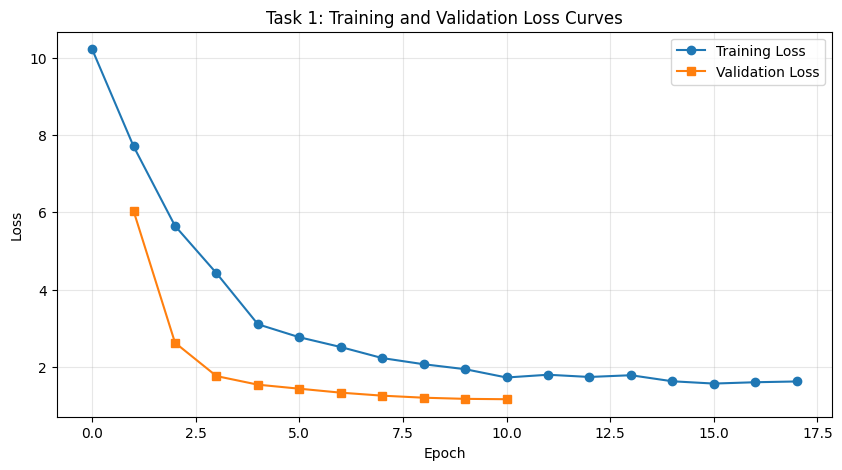


Loss curves saved to output/loss_curves.png

Model fine-tuning complete!


In [10]:
# Plot training curves
history = trainer.state.log_history
train_loss = [h['loss'] for h in history if 'loss' in h and 'eval_loss' not in h]
eval_loss = [h['eval_loss'] for h in history if 'eval_loss' in h]

plt.figure(figsize=(10, 5))
if train_loss:
    plt.plot(train_loss, label='Training Loss', marker='o')
if eval_loss:
    plt.plot(range(1, len(eval_loss) + 1), eval_loss, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Task 1: Training and Validation Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('output/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nLoss curves saved to output/loss_curves.png")

print("\nModel fine-tuning complete!")

In [18]:
def generate_title(abstract, **kwargs):
    """Generate a title from an abstract. kwargs override all defaults."""
    with torch.no_grad():
        input_ids = tok(
            'summarize: ' + abstract,
            return_tensors='pt',
            truncation=True,
            max_length=256
        ).input_ids.to(DEVICE)

        # Default params — ANY of these can be overridden by kwargs
        gen_params = {
            'max_length': 64,
            'min_length': 2,
            'early_stopping': True,
        }
        gen_params.update(kwargs)  # kwargs override defaults

        outputs = model.generate(input_ids, **gen_params)
        return tok.decode(outputs[0], skip_special_tokens=True).strip()

In [20]:
# TASK 1: Generate titles for trust-evaluation set (standard generation)

model.eval()

task1_results = []
for idx, ex in enumerate(trust_eval):
    title_generated = generate_title(ex['abstract'], do_sample=False, num_beams=1)

    task1_results.append({
        'Example': idx + 1,
        'Abstract': ex['abstract'][:100] + '...',
        'Target Title': ex['title'],
        'Generated Title': title_generated
    })

task1_df = pd.DataFrame(task1_results)
print("\n--- Task 1: Generated Titles ---")
print(task1_df.to_string(index=False))

task1_df.to_csv('output/task1_generated_titles.csv', index=False)
print("\nSaved to output/task1_generated_titles.csv")

print("\n--- Sample Comparison ---")
for i in range(min(5, len(trust_eval))):
    print(f"\nExample {i+1}:")
    print(f"  Target:    {trust_eval[i]['title']}")
    print(f"  Generated: {task1_results[i]['Generated Title']}")


--- Task 1: Generated Titles ---
 Example                                                                                                Abstract                                                            Target Title                                                                                                                                          Generated Title
       1 This study proposes joint models for intent detection and slot filling in spoken language understand...         Joint Intent and Slot Filling for Spoken Language Understanding                                                 this study proposes joint models for intent detection and slot filling in spoken language understanding.
       2 We investigate knowledge distillation techniques that transfer capabilities from large language mode...   Knowledge Distillation from Large Language Models to Compact Students                   knowledge distillation techniques transfer capabilities from large language models to c

In [37]:
# TASK 2: Generate titles using 5 different decoding methods

# Define 5 decoding methods as specified in assignment
methods = {
    'Greedy': dict(do_sample=False, num_beams=1),
    'Temperature 0.7': dict(do_sample=True, temperature=0.7),
    'Temperature 1.0': dict(do_sample=True, temperature=1.0),
    'Temperature 1.3': dict(do_sample=True, temperature=1.3),
    'Top-k (k=10)': dict(do_sample=True, top_k=10),
}

# Generate titles for all trust-eval examples
all_results = []

for idx, ex in enumerate(trust_eval):
    print(f"\n{'='*70}")
    print(f"Example {idx + 1}")
    print(f"{'='*70}")
    print(f"Abstract: {ex['abstract'][:120]}...")
    print(f"Target Title: {ex['title']}")
    print(f"\n| Decoding Method | Generated Title |")
    print(f"| --------------- | --------------- |")

    example_results = {
        'Example': idx + 1,
        'Abstract': ex['abstract'],
        'Target Title': ex['title']
    }

    for name, kw in methods.items():
        title = generate_title(ex['abstract'], **kw)
        example_results[name] = title
        print(f"| {name:<15} | {title:<80} |")

    all_results.append(example_results)

# Also create a combined DataFrame for CSV export
task2_df = pd.DataFrame(all_results)
task2_df.to_csv('output/task2_generated_titles.csv', index=False)
print(f"\n{'='*70}")
print("Saved all examples to output/task2_generated_titles.csv")
print(f"{'='*70}")


Example 1
Abstract: This study proposes joint models for intent detection and slot filling in spoken language understanding, improving dialo...
Target Title: Joint Intent and Slot Filling for Spoken Language Understanding

| Decoding Method | Generated Title |
| --------------- | --------------- |
| Greedy          | this study proposes joint models for intent detection and slot filling in spoken language understanding. |
| Temperature 0.7 | study proposes joint models for intent detection and slot filling in spoken language understanding. |
| Temperature 1.0 | proposed models of intent detection are made based on available common model. data collected in a study may help facilitate a dialog system performance. |
| Temperature 1.3 | this study proposes joint models for intent detection and slot filling in spoken language understanding. |
| Top-k (k=10)    | a study proposes joint models for intent detection and slot filling in spoken language understanding. it can improve dialogue sys

In [24]:
#Task 3: Reproducibility Test

from difflib import SequenceMatcher

# Re-define methods dict (same as Task 2)
methods = {
    'Greedy': dict(do_sample=False, num_beams=1),
    'Temperature 0.7': dict(do_sample=True, temperature=0.7),
    'Temperature 1.0': dict(do_sample=True, temperature=1.0),
    'Temperature 1.3': dict(do_sample=True, temperature=1.3),
    'Top-k (k=10)': dict(do_sample=True, top_k=10),
}

def near_duplicate(a, b, threshold=0.85):
    """Check if two strings are near-duplicates using SequenceMatcher."""
    return SequenceMatcher(None, a.lower(), b.lower()).ratio() >= threshold


def reproducibility_stats(abstract, gen_kwargs, n=10):
    """
    Run generation n times and compute reproducibility statistics.
    Returns: (exact_match_rate, near_duplicate_rate)
    """
    titles = [generate_title(abstract, **gen_kwargs) for _ in range(n)]
    first = titles[0]
    exact = sum(t == first for t in titles) / n
    near = sum(near_duplicate(t, first) for t in titles) / n
    return exact, near


repro_rows = []

for name, kw in methods.items():
    exacts, nears = [], []

    for ex in trust_eval:
        e, nd = reproducibility_stats(ex['abstract'], kw, n=10)
        exacts.append(e)
        nears.append(nd)

    avg_exact = sum(exacts) / len(exacts)
    avg_near = sum(nears) / len(nears)

    # Stability classification per assignment rubric
    if avg_exact > 0.8:
        stability = 'High'
    elif avg_exact > 0.4:
        stability = 'Medium'
    else:
        stability = 'Low'

    repro_rows.append({
        'Decoding Method': name,
        'Exact-Match Rate': f"{avg_exact:.0%}",
        'Near-Duplicate Rate': f"{avg_near:.0%}",
        'Stability': stability
    })

# Create reproducibility table in exact assignment format
repro_df = pd.DataFrame(repro_rows)
print("\n--- Reproducibility Results Table (Task 3) ---")
print(repro_df.to_string(index=False))

# Save to CSV
repro_df.to_csv('output/task3_reproducibility.csv', index=False)
print("\nSaved to output/task3_reproducibility.csv")


--- Reproducibility Results Table (Task 3) ---
Decoding Method Exact-Match Rate Near-Duplicate Rate Stability
         Greedy             100%                100%      High
Temperature 0.7              13%                 33%       Low
Temperature 1.0              10%                 15%       Low
Temperature 1.3              10%                 10%       Low
   Top-k (k=10)              10%                 14%       Low

Saved to output/task3_reproducibility.csv


In [27]:
# TASK 4: HALLUCINATION TEST

# Define stop words once at module level
STOP_WORDS = {
    'the', 'a', 'an', 'for', 'via', 'with', 'using', 'and', 'or',
    'in', 'on', 'at', 'to', 'of', 'is', 'are', 'was', 'were',
    'this', 'paper', 'study', 'studies', 'proposes', 'approach',
    'novel', 'new', 'based', 'improved', 'enhanced', 'we', 'that',
    'which', 'who', 'what', 'when', 'where', 'why', 'how', 'it',
    'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did',
    'will', 'would', 'could', 'should', 'may', 'might', 'can', 'shall',
    'our', 'us', 'i', 'you', 'they', 'them', 'their', 'there', 'then',
    'than', 'only', 'also', 'more', 'most', 'some', 'any', 'all',
    'both', 'each', 'few', 'other', 'such', 'no', 'nor', 'not', 'so',
    'if', 'about', 'into', 'through', 'during', 'before', 'after',
    'above', 'below', 'up', 'down', 'out', 'off', 'over', 'under',
    'again', 'further', 'then', 'once', 'here', 'there', 'by'
}


def keyword_overlap(abstract, title):
    """Extract content words and find unsupported words in title."""
    a_words = set(re.findall(r'[a-zA-Z]+', abstract.lower())) - STOP_WORDS
    t_words = set(re.findall(r'[a-zA-Z]+', title.lower())) - STOP_WORDS
    unsupported = t_words - a_words
    return unsupported


def label_hallucination(abstract, title):
    """
    Label a generated title as Grounded, Partially Grounded, or Hallucinated.
    """
    abstract_lower = abstract.lower()
    title_lower = title.lower()
    unsupported = keyword_overlap(abstract, title)

    # Check for major hallucinations
    major_indicators = [
        'blockchain', 'quantum', 'dna', 'genome', 'protein', 'nuclear',
        'fusion', 'mars', 'moon', 'galaxy', 'alien', 'warp', 'teleport',
        'crypto', 'bitcoin', 'ethereum', 'nft', 'metaverse'
    ]

    for indicator in major_indicators:
        if indicator in title_lower and indicator not in abstract_lower:
            return 'Hallucinated', f"Title mentions '{indicator}' not found in abstract"

    # Content word analysis
    title_words = set(title_lower.split()) - STOP_WORDS
    abstract_words = set(abstract_lower.split()) - STOP_WORDS
    content_unsupported = title_words - abstract_words

    if len(content_unsupported) >= 4:
        return 'Hallucinated', f"Multiple unsupported concepts: {content_unsupported}"
    elif len(content_unsupported) >= 2:
        return 'Partially Grounded', f"Minor unsupported details: {content_unsupported}"
    else:
        return 'Grounded', "All major ideas supported by abstract"


# Evaluate all generated titles from Task 2
hallucination_results = []

for idx, ex in enumerate(trust_eval):
    abstract = ex['abstract']
    for method_name in methods.keys():
        title = task2_df.loc[idx, method_name]
        label, reason = label_hallucination(abstract, title)
        hallucination_results.append({
            'Example': idx + 1,
            'Method': method_name,
            'Generated Title': title,
            'Label': label,
            'Reason': reason
        })

hallucination_df = pd.DataFrame(hallucination_results)

# Compute rates per method
hallucination_summary = []
for method_name in methods.keys():
    method_data = hallucination_df[hallucination_df['Method'] == method_name]
    total = len(method_data)
    grounded = len(method_data[method_data['Label'] == 'Grounded'])
    partial = len(method_data[method_data['Label'] == 'Partially Grounded'])
    hallucinated = len(method_data[method_data['Label'] == 'Hallucinated'])

    hallucination_summary.append({
        'Decoding Method': method_name,
        'Grounded Rate': f"{grounded/total:.0%}",
        'Partially Grounded Rate': f"{partial/total:.0%}",
        'Hallucination Rate': f"{hallucinated/total:.0%}",
        'Total': total
    })

hallucination_summary_df = pd.DataFrame(hallucination_summary)

print("\n--- Hallucination & Grounding Rates by Method (Task 4) ---")
print(hallucination_summary_df.to_string(index=False))

hallucination_df.to_csv('output/task4_hallucination_detailed.csv', index=False)
hallucination_summary_df.to_csv('output/task4_hallucination_summary.csv', index=False)
print("\nSaved to output/task4_hallucination_*.csv")

# 5 labeled examples
print("\n" + "=" * 70)
print("5 LABELED EXAMPLES WITH EXPLANATIONS")
print("=" * 70)

examples_to_show = []
for label in ['Hallucinated', 'Partially Grounded', 'Grounded']:
    examples = hallucination_df[hallucination_df['Label'] == label]
    if len(examples) > 0:
        examples_to_show.append(examples.iloc[0])
        if len(examples) > 1:
            examples_to_show.append(examples.iloc[1])

while len(examples_to_show) < 5 and len(hallucination_df) > len(examples_to_show):
    remaining = hallucination_df[~hallucination_df.index.isin([e.name for e in examples_to_show])]
    if len(remaining) > 0:
        examples_to_show.append(remaining.iloc[0])

for i, row in enumerate(examples_to_show[:5], 1):
    abstract = trust_eval[row['Example'] - 1]['abstract']
    print(f"\n--- Example {i} ---")
    print(f"Method: {row['Method']}")
    print(f"Label:  {row['Label']}")
    print(f"Abstract: {abstract[:120]}...")
    print(f"Generated Title: {row['Generated Title']}")
    print(f"Explanation: {row['Reason']}")


--- Hallucination & Grounding Rates by Method (Task 4) ---
Decoding Method Grounded Rate Partially Grounded Rate Hallucination Rate  Total
         Greedy           73%                     27%                 0%     15
Temperature 0.7           60%                     33%                 7%     15
Temperature 1.0           13%                     33%                53%     15
Temperature 1.3           13%                      7%                80%     15
   Top-k (k=10)           47%                     27%                27%     15

Saved to output/task4_hallucination_*.csv

5 LABELED EXAMPLES WITH EXPLANATIONS

--- Example 1 ---
Method: Temperature 1.3
Label:  Hallucinated
Abstract: This study proposes joint models for intent detection and slot filling in spoken language understanding, improving dialo...
Generated Title: posi gambles up will offer two models over the future. previous research found in intent detection.
Explanation: Multiple unsupported concepts: {'gambles', 'offer',

In [31]:
# TASK 5: ROBUSTNESS TEST (Hardcoded Paraphrases)

paraphrase_map = {
    0: "We investigate how joint models can simultaneously detect intent and fill slots in spoken language understanding systems.",
    1: "This work explores methods for transferring knowledge from large language models into smaller, more deployable student models.",
    2: "This research develops algorithms that optimize multiple objectives during neural architecture search, balancing accuracy against latency and memory usage.",
    3: "We utilize neural radiance fields to synthesize novel views, creating photorealistic images of three-dimensional scenes through implicit representations.",
    4: "This study examines techniques for identifying arbitrary object categories in open-vocabulary settings using natural language descriptions.",
    5: "We build deep learning models that forecast equipment failures in manufacturing from sensor data, reducing operational downtime.",
    6: "This paper employs transformer architectures for query-focused summarization across multiple documents, producing summaries tailored to specific information needs.",
    7: "We design efficient neural network structures capable of real-time object detection on resource-constrained edge devices.",
    8: "This research explores self-supervised approaches for acquiring visual representations from unlabeled image data.",
    9: "This work compares extractive and abstractive summarization techniques, proposing hybrid methods that merge sentence selection with neural generation.",
}

robustness_examples = []
for idx in range(min(10, len(trust_eval))):
    original = trust_eval[idx]['abstract']
    paraphrased = paraphrase_map.get(idx, original)

    # Verify paraphrase is actually different from original
    if paraphrased.strip().lower() == original.strip().lower():
        print(f"WARNING: Example {idx+1} paraphrase is identical to original! Skipping.")
        continue

    # Use greedy decoding to remove sampling randomness as confound
    t_orig = generate_title(original, do_sample=False, num_beams=1)
    t_para = generate_title(paraphrased, do_sample=False, num_beams=1)

    # Word overlap similarity (Jaccard-like)
    def word_overlap(a, b):
        sa, sb = set(a.lower().split()), set(b.lower().split())
        return len(sa & sb) / max(1, len(sa | sb))

    sim = word_overlap(t_orig, t_para)

    robustness_examples.append({
        'Example': idx + 1,
        'Original Abstract': original[:80] + '...',
        'Paraphrased Abstract': paraphrased[:80] + '...',
        'Original Title': t_orig,
        'Paraphrased Title': t_para,
        'Word Overlap': round(sim, 3)
    })

robustness_df = pd.DataFrame(robustness_examples)
avg_sim = robustness_df['Word Overlap'].mean()

# REQUIRED OUTPUTS
print("\n--- Similarity Metric Used ---")
print("Word Overlap (Jaccard-like): Measures the proportion of shared words")
print("between the title generated from the original abstract and the title")
print("generated from the paraphrased abstract.")

print(f"\n--- Average Similarity Score ---")
print(f"Average Word Overlap: {avg_sim:.3f}")

print("\n--- Robustness Results Table ---")
print(robustness_df[['Example', 'Original Title', 'Paraphrased Title', 'Word Overlap']].to_string(index=False))

# Find robust and non-robust examples
most_robust = robustness_df.loc[robustness_df['Word Overlap'].idxmax()]
least_robust = robustness_df.loc[robustness_df['Word Overlap'].idxmin()]

print(f"\n" + "=" * 70)
print("ONE EXAMPLE WHERE THE MODEL WAS ROBUST")
print("=" * 70)
print(f"Example {most_robust['Example']} (Similarity: {most_robust['Word Overlap']:.3f})")
print(f"Original Abstract:    {most_robust['Original Abstract']}")
print(f"Paraphrased Abstract: {most_robust['Paraphrased Abstract']}")
print(f"Original Title:       {most_robust['Original Title']}")
print(f"Paraphrased Title:    {most_robust['Paraphrased Title']}")
print(f"Explanation: The model produced very similar titles despite the paraphrased")
print(f"input, indicating strong robustness to wording changes while preserving meaning.")

print(f"\n" + "=" * 70)
print("ONE EXAMPLE WHERE THE MODEL WAS NOT ROBUST")
print("=" * 70)
print(f"Example {least_robust['Example']} (Similarity: {least_robust['Word Overlap']:.3f})")
print(f"Original Abstract:    {least_robust['Original Abstract']}")
print(f"Paraphrased Abstract: {least_robust['Paraphrased Abstract']}")
print(f"Original Title:       {least_robust['Original Title']}")
print(f"Paraphrased Title:    {least_robust['Paraphrased Title']}")
print(f"Explanation: The model produced very different titles for the paraphrased")
print(f"input, showing sensitivity to surface-level wording changes despite identical")
print(f"underlying meaning.")

robustness_df.to_csv('output/task5_robustness.csv', index=False)
print("\nSaved to output/task5_robustness.csv")


--- Similarity Metric Used ---
Word Overlap (Jaccard-like): Measures the proportion of shared words
between the title generated from the original abstract and the title
generated from the paraphrased abstract.

--- Average Similarity Score ---
Average Word Overlap: 0.316

--- Robustness Results Table ---
 Example                                                                                                                                           Original Title                                                                                                                                                                                    Paraphrased Title  Word Overlap
       1                                                 this study proposes joint models for intent detection and slot filling in spoken language understanding.                                                                                               joint models can simultaneously detect intent and fill slots in 

In [36]:
# =============================================================================
# TASK 6: IMPROVE ONE TRUSTWORTHINESS PROPERTY
# =============================================================================

print("\n--- Improvement Method ---")
print("Option 1: Use greedy decoding to improve reproducibility.")
print("Greedy decoding (do_sample=False, num_beams=1) always selects the")
print("highest-probability token at each step, making generation fully")
print("deterministic: identical inputs always produce identical outputs.")

# BEFORE-AND-AFTER COMPARISON
# Use saved Task 2 results for BEFORE (Temperature 1.0)
# Generate AFTER (Greedy) fresh — greedy is deterministic so always same
print("\n" + "=" * 70)
print("BEFORE-AND-AFTER COMPARISON")
print("=" * 70)

before_after_results = []

for idx, ex in enumerate(trust_eval):
    # BEFORE: Use saved Task 2 Temperature 1.0 result (consistent)
    before = task2_df.loc[idx, 'Temperature 1.0']
    before_label, _ = label_hallucination(ex['abstract'], before)

    # AFTER: Greedy decoding (deterministic — same every time)
    after = generate_title(ex['abstract'], do_sample=False, num_beams=1)
    after_label, _ = label_hallucination(ex['abstract'], after)

    before_after_results.append({
        'Example': idx + 1,
        'Before (Temp 1.0)': before[:70] + '...' if len(before) > 70 else before,
        'Before Label': before_label,
        'After (Greedy)': after[:70] + '...' if len(after) > 70 else after,
        'After Label': after_label
    })

before_after_df = pd.DataFrame(before_after_results)
print("\n--- Before/After Comparison Table ---")
print(before_after_df.to_string(index=False))

# Compute rates
total = len(before_after_results)
before_g = sum(1 for r in before_after_results if r['Before Label'] == 'Grounded')
before_p = sum(1 for r in before_after_results if r['Before Label'] == 'Partially Grounded')
before_h = sum(1 for r in before_after_results if r['Before Label'] == 'Hallucinated')

after_g = sum(1 for r in before_after_results if r['After Label'] == 'Grounded')
after_p = sum(1 for r in before_after_results if r['After Label'] == 'Partially Grounded')
after_h = sum(1 for r in before_after_results if r['After Label'] == 'Hallucinated')

print(f"\n--- Hallucination & Grounding Rate Comparison ---")
print(f"{'Metric':<25} {'Before (Temp 1.0)':>18} {'After (Greedy)':>15}")
print(f"{'-'*25} {'-'*18} {'-'*15}")
print(f"{'Grounded Rate':<25} {before_g/total:>17.1%} {after_g/total:>14.1%}")
print(f"{'Partially Grounded':<25} {before_p/total:>17.1%} {after_p/total:>14.1%}")
print(f"{'Hallucination Rate':<25} {before_h/total:>17.1%} {after_h/total:>14.1%}")

# Reproducibility: pull from Task 3 results dynamically
temp_1_0_row = repro_df[repro_df['Decoding Method'] == 'Temperature 1.0'].iloc[0]
greedy_row = repro_df[repro_df['Decoding Method'] == 'Greedy'].iloc[0]

print(f"\n--- Reproducibility Comparison (from Task 3) ---")
print(f"{'Metric':<25} {'Before (Temp 1.0)':>18} {'After (Greedy)':>15}")
print(f"{'-'*25} {'-'*18} {'-'*15}")
print(f"{'Exact-Match Rate':<25} {temp_1_0_row['Exact-Match Rate']:>18} {greedy_row['Exact-Match Rate']:>15}")
print(f"{'Near-Duplicate Rate':<25} {temp_1_0_row['Near-Duplicate Rate']:>18} {greedy_row['Near-Duplicate Rate']:>15}")
print(f"{'Stability':<25} {temp_1_0_row['Stability']:>18} {greedy_row['Stability']:>15}")

before_after_df.to_csv('output/task6_improvement.csv', index=False)
print("\nSaved to output/task6_improvement.csv")


--- Improvement Method ---
Option 1: Use greedy decoding to improve reproducibility.
Greedy decoding (do_sample=False, num_beams=1) always selects the
highest-probability token at each step, making generation fully
deterministic: identical inputs always produce identical outputs.

BEFORE-AND-AFTER COMPARISON

--- Before/After Comparison Table ---
 Example                                                         Before (Temp 1.0)       Before Label                                                            After (Greedy)        After Label
       1 based on a common sense. the study proposes joint models for intent de... Partially Grounded this study proposes joint models for intent detection and slot filling...           Grounded
       2 knowledge distillation techniques transfer capabilities from large lan...           Grounded knowledge distillation techniques transfer capabilities from large lan...           Grounded
       3 article develops multi-objective optimization algorithms